<a href="https://colab.research.google.com/github/akshaya-02ly/lab-7.5/blob/main/spop_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install seaborn transformers

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
from google.colab import files
import pandas as pd

# Upload file from your system
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv(list(uploaded.keys())[0])

# Show data
df.head()

Saving parking.csv to parking (1).csv


,id,image,mask
0,0,images/0.png,boxes/0.png
1,1,images/1.png,boxes/1.png
2,2,images/2.png,boxes/2.png
3,3,images/3.png,boxes/3.png
4,4,images/4.png,boxes/4.png


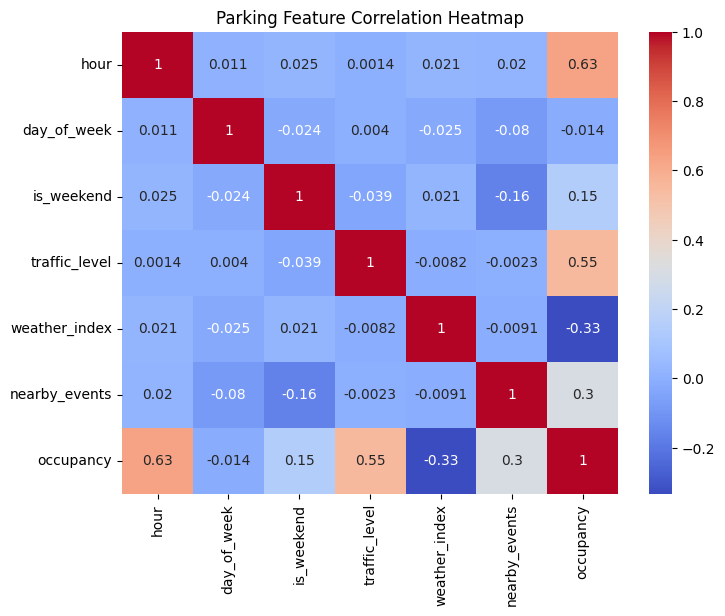

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Parking Feature Correlation Heatmap")
plt.show()

In [6]:
X = df.drop("occupancy", axis=1)
y = df["occupancy"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=200)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "R2": r2}
    predictions[name] = y_pred

    print(f"\n{name}")
    print("MSE:", round(mse,2))
    print("R²:", round(r2,2))


Linear Regression
MSE: 23.13
R²: 0.94

Ridge
MSE: 23.06
R²: 0.94

Lasso
MSE: 26.36
R²: 0.93

Random Forest
MSE: 72.75
R²: 0.81


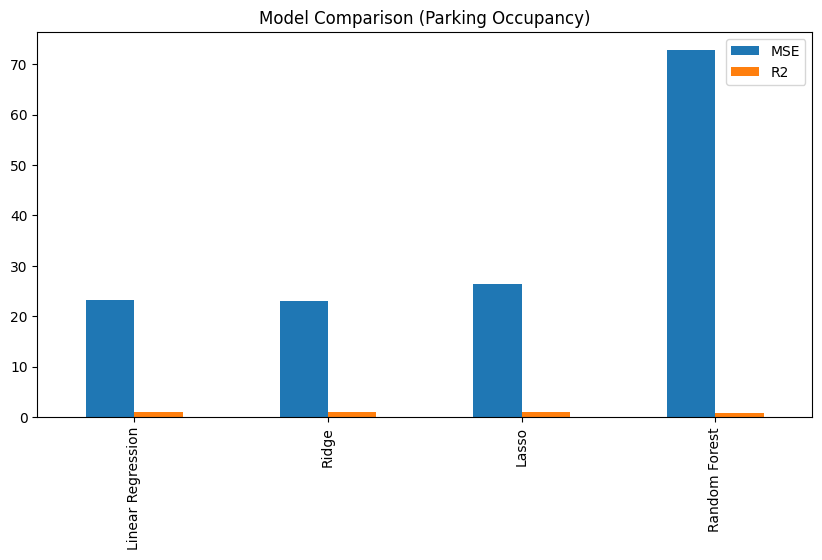

In [8]:
results_df = pd.DataFrame(results).T

results_df.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison (Parking Occupancy)")
plt.show()

In [9]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Ridge


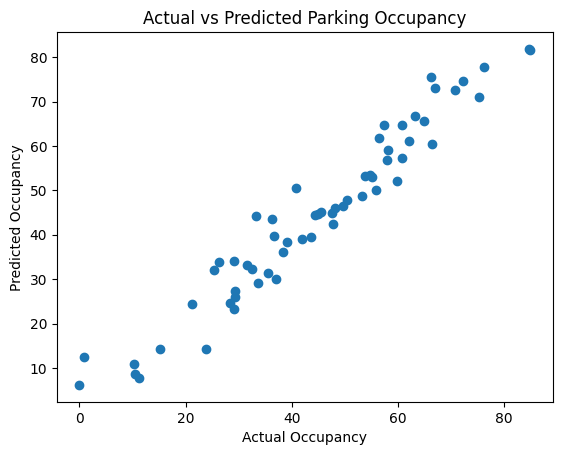

In [10]:
y_pred_best = predictions[best_model_name]

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Occupancy")
plt.ylabel("Predicted Occupancy")
plt.title("Actual vs Predicted Parking Occupancy")
plt.show()

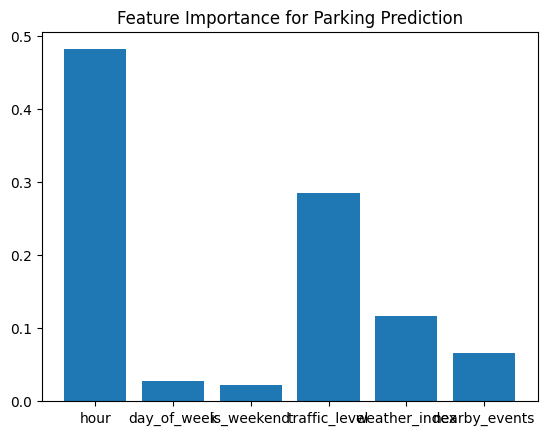

In [11]:
rf_model = models["Random Forest"]

importance = rf_model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance for Parking Prediction")
plt.show()

In [12]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

feedback = "Parking area is too crowded and difficult to find space"

result = classifier(feedback)

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9997633099555969}]


In [13]:
if result[0]['label'] == 'NEGATIVE':
    print("⚠ High parking congestion detected from feedback")

⚠ High parking congestion detected from feedback


In [14]:
# Example input:
# hour, day_of_week, is_weekend, traffic_level, weather_index, nearby_events

new_data = [[18, 5, 1, 8, 3, 1]]

new_scaled = scaler.transform(new_data)
predicted_occupancy = best_model.predict(new_scaled)[0]

print("Predicted Parking Occupancy:", round(predicted_occupancy,2), "%")

Predicted Parking Occupancy: 93.0 %


In [15]:
if predicted_occupancy > 80:
    status = "Full 🚫"
elif predicted_occupancy > 50:
    status = "Moderate ⚠"
else:
    status = "Available ✅"

print("Parking Status:", status)

Parking Status: Full 🚫
